In [1]:
import imageio.v2 as iio
import numpy as np
import matplotlib.pyplot as plt
import math

img=iio.imread("/content/sample_data/moon.tif")
#print(img.shape)
#print(img)

img2=iio.imread("/content/sample_data/colors.tif")
print(img2.shape)

R=img2[:,:,0]
G=img2[:,:,1]
B=img2[:,:,2]

(1040, 1040, 3)


[[1 1 1]
 [1 1 1]
 [1 1 1]]


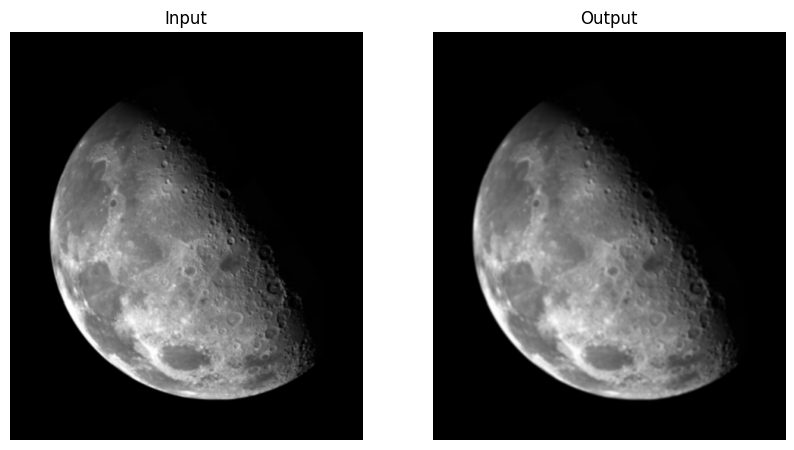

In [2]:
img3=np.copy(img)
isize=np.shape(img3)
row=isize[0]
col=isize[1]

h=np.array([[1,1,1],[1,1,1],[1,1,1]])
print(h)

def smooth(arr1,arr2):
    ztemp=arr1*arr2
    z=np.mean(ztemp)
    return(z)

for i in range(1,row-1):
    for j in range(1,col-1):
        img3[i,j]=smooth(img[i-1:i+2,j-1:j+2],h)

#plotting figure
fig=plt.figure(figsize=(10,7))
nrow=1
ncol=2
fig.add_subplot(nrow,ncol,1)
plt.imshow(img,cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('Input')

fig.add_subplot(nrow,ncol,2)
plt.imshow(img3,cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('Output')
plt.show()

[  9   9   9 ... 493 493 526] [ 534  535  569 ...  543  545 1012]
9 526 460 1012


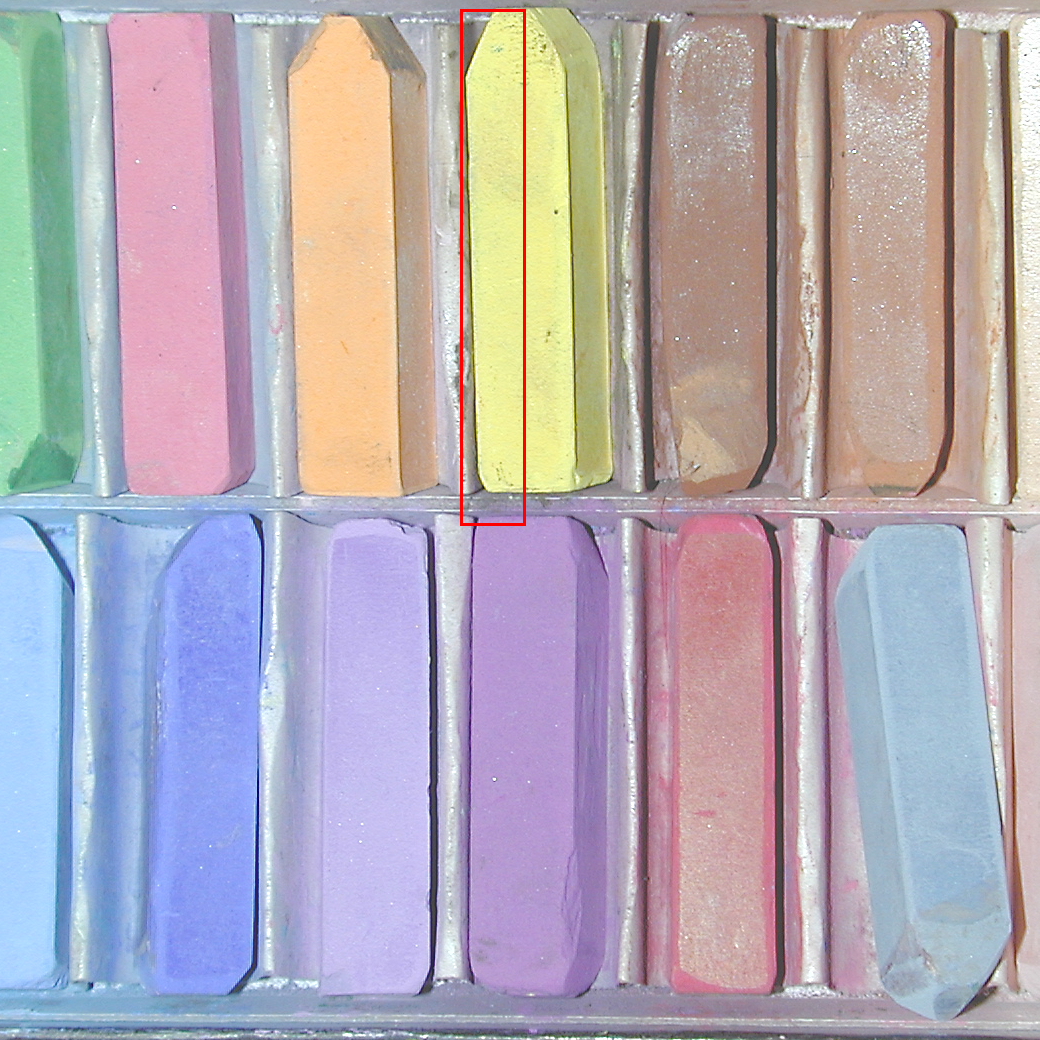

In [14]:
import cv2
from google.colab.patches import cv2_imshow
img=cv2.imread('/content/sample_data/colors.tif')#OpenCV loads in BGR format
#img2=cv2.cvtColor(src=img,code=cv2.COLOR_BGR2RGB)#To convert from RGB to BGR
B=img[:,:,0]#Blue Channel
G=img[:,:,1]#Green Channel
R=img[:,:,2]#Red Channel

isize=np.shape(img)
nrow=isize[0]
ncol=isize[1]

img1c=np.copy(img)
img2=np.stack((R,G,B),axis=2)# axis=0 (for rows), 1 (for columns), 2 (for depth)

img3=cv2.cvtColor(src=img,code=cv2.COLOR_BGR2HSV)
h=img3[:,:,0]# Hue (Color:0-179)
s=img3[:,:,1]# Saturation (Intensity (Amount of white light mixed):0-255)
v=img3[:,:,2]# Value (Brightness: 0-255)




mask=(h>=28)&(h<=40)&(s>100)&(v>50)#Detects Yellow
#mask=(h>=40)&(h<=80)&(s>75)&(v>20)&(v<100)
#mask = (h >= 27) & (h <= 34) & (s > 85) & (v > 200)
y_coord,x_coord=np.where(mask)

if(len(y_coord)>0):
    y_min,y_max=np.min(y_coord),np.max(y_coord)
    x_min,x_max=np.min(x_coord),np.max(y_coord)
    t=3
    mcolor=[0,0,255]#Red box with thickness=3
    img1c[y_min:y_min+t,x_min:x_max,:]=mcolor
    img1c[y_max-t:y_max,x_min:x_max,:]=mcolor
    img1c[y_min:y_max,x_min:x_min+t,:]=mcolor
    img1c[y_min:y_max,x_max-t:x_max,:]=mcolor

print(y_coord,x_coord)
print(min(y_coord),max(y_coord),min(x_coord),max(x_coord))
cv2_imshow(img1c)
cv2.waitKey(0) #Wait forever till any key is pressed
cv2.destroyAllWindows()